# black-box regression results

Generates figures comparing performance on the black-box regression problems.

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

import sys; sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

if True: # Off-the-shelf evaluation
    rdir  = '../../results/black-box/'
    figdir = f'../figs/black-box/'
else: # with HP tuning
    rdir  = '../../results/black-box-tuned/'
    figdir = f'../figs/black-box-tuned/'

datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')


# read data from feather

In [2]:
df_results = pd.read_feather(rdir+'results.feather')
df_sum = pd.read_csv(rdir+'results-summary.csv.gz', compression='gzip')

print('mean trial count:')
print(df_results.groupby('algorithm')['dataset'].count().sort_values()
      / df_results.dataset.nunique())

mean trial count:
algorithm
E2E                   19.083333
NeSymRes              24.916667
TPSR                  25.000000
PYSR                  27.500000
EQL                   27.500000
Operon                27.583333
FEAT                  29.416667
TIR                   29.583333
AFP                   30.000000
Rils-Rols             30.000000
QLattice              30.000000
PS-Tree               30.000000
ITEA                  30.000000
Genetic Engine rs     30.000000
Genetic Engine hc     30.000000
Genetic Engine        30.000000
gplearn               30.000000
GPZGD                 30.000000
GP-GOMEA              30.000000
FFX                   30.000000
EPLEX                 30.000000
Brush                 30.000000
Bingo                 30.000000
BSR                   30.000000
AFP_FE                30.000000
AFP_EHC               30.000000
Genetic Engine 1p1    30.000000
uDSR                  30.000000
Name: dataset, dtype: float64


## summarize results by dataset, including ranking

# plot comparisons

In [3]:
def compare(df_compare, x='r2_test',y='algorithm', row=None, col=None, scale=None, xlim=[],**kwargs):
    plt.figure()
    order = df_compare.groupby(y)[x].median().sort_values(ascending=False).index
    if scale=='log' and len(xlim)>0 and xlim[0] == 0:
        df_compare.loc[:,x] += 1
        xlim[0] = 1
        xnew = '1 + '+x
        df_compare=df_compare.rename(columns={x:xnew})
        x = xnew
    
    sns.catplot(data=df_compare, 
                kind='point',
                y=y,
                x=x,
                order=order,
                fliersize=0,
                row=row,
                col=col,
                **kwargs
               )

    plt.ylabel('')
    if len(xlim)>0:
        plt.xlim(xlim[0],xlim[1])
    if scale:
        plt.gca().set_xscale(scale)
    
    save(name='_'.join(['cat-boxplot',x + '-by-'+ y]) )
    if col:
        save(name='_'.join(['cat-boxplot',x + '-by-'+ y] + [col]) )

## point plot comparisons on PMLB

saving ../figs/black-box//pairgrid-pointplot_r2_test_model_size_training-time-(s).pdf


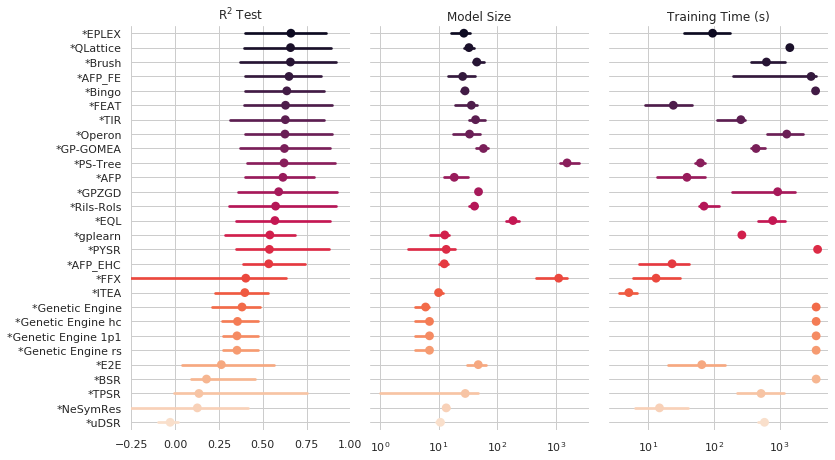

In [4]:
# Make the PairGrid
df_plot=df_sum.copy()

# different options
x_vars=[
#       'rmse_test',
#         'log_mse_test',
#         'r2_test_norm',
        'r2_test',
#         'r2_test_rank',
        'model_size',
#         'model_size_rank',
        'training time (s)',
]

order = df_plot.groupby('*algorithm*')[x_vars[0]].median().sort_values(
                    ascending='r2' not in x_vars[0] or 'rank' in x_vars[0]).index

g = sns.PairGrid(df_plot, 
                 x_vars=x_vars,
                 y_vars=['*algorithm*'],
                 height=6.5, 
                 aspect=0.6,
                 hue_order=order,
                 palette=sns.color_palette("rocket", n_colors=len(order)),
                )

# Draw a dot plot 
g.map(sns.pointplot, 
      orient="h",
      order=order,
      palette=sns.color_palette("rocket", n_colors=len(order)),
      join=False,
      estimator=np.median,
      n_boot=1000,
      ci=95
     )

# # Use semantically meaningful titles for the columns
titles = [x.replace('_',' ').title().replace('(S)','(s)').replace('R2','$R^2$') for x in x_vars]
g.axes.flat[0].set_ylabel('')

for ax, title in zip(g.axes.flat, titles):
    # Set a different title for each axes
    ax.set(title=title)
    ax.set_xlabel('')
    
    if any([n in title.lower() for n in ['size','time']]):
        ax.set_xscale('log')
    
    if title == '$R^2$ Test':
        ax.set_xlim([-.25,1])

    # Make the grid horizontal instead of vertical
    ax.yaxis.grid(True)

sns.despine(left=True, bottom=True)
save(name='_'.join(['pairgrid-pointplot']+x_vars))

## effect of friedman datasets

saving ../figs/black-box//friedman_comparison_pairgrid-pointplot_normalized_R2_test.pdf


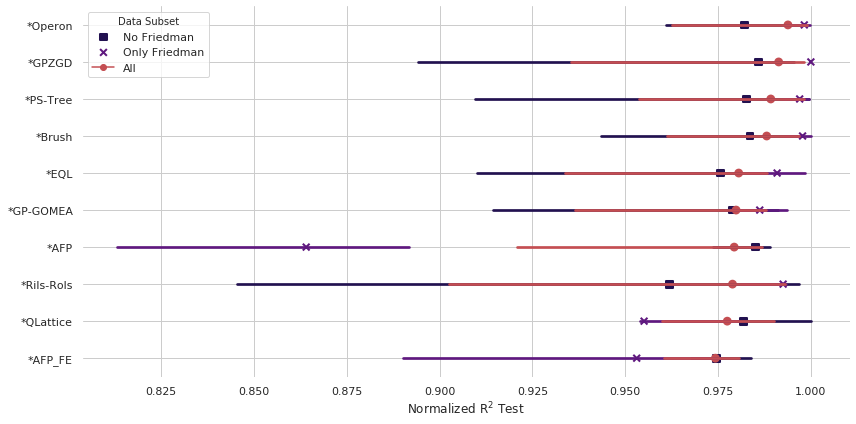

In [5]:
# Make the PairGrid
df_plot = df_sum.copy()[['*algorithm*','r2_test','r2_test_norm','r2_test_rank','friedman_dataset']]

x='r2_test'
markers = ['o','s','x']
colors = sns.color_palette('rocket',n_colors=3)

for x in ['r2_test_norm']:
    h = plt.figure(figsize=(12,6))
    ax = plt.gca()

    # Change here to show only first N algorithms
    order = df_plot.groupby('*algorithm*')[x].median().sort_values(
                ascending='r2' not in x or 'rank' in x).index[:10].tolist()

    i = 0
    axes = []
    g = sns.pointplot(ax=ax,
                  data=df_plot,
                  x=x,
                  y='*algorithm*',
                  hue='friedman_dataset',
                  orient="h",
                  order=order,
                  markers=['s','x'],
                  join=False,
                  estimator=np.median,
                 )

    # all PMLB
    g2 = sns.pointplot(ax=ax,
                  data=df_plot,
                  x=x,
                  y='*algorithm*',
                  orient="h",
                  order=order,
                  color='r',
                  join=False,
                  estimator=np.median,
                  markers = ['o']
                 )

    # add all PMLB to legend
    handles, labels = ax.get_legend_handles_labels()
    #Create custom artists
    both = plt.Line2D((0,1),(0,0), color='r', marker='o', linestyle='-', label='All')
    handles.append(both)
    plt.legend(title='Data Subset',
               handles=handles, 
               labels=['No Friedman','Only Friedman','All'])
    
    if x=='r2_test':
        plt.xlim([-.5,1.0])
    if 'norm' in x:
        x='normalized_R2_test'
    sns.despine(left=True, bottom=True)
#         plt.title(prefix.replace('_',' ').title())
    axes.append(ax)
    i+=1
    plt.tight_layout()
    for ax in axes:
        ax.set_ylabel('')
        ax.set_xlabel(x.replace('_',' ').title().replace('(S)','(s)').replace('R2','$R^2$'))
        ax.yaxis.grid(True)
        ax.xaxis.grid(True)

    save(name='friedman_comparison_'+'_'.join(['pairgrid-pointplot']+[x]))

# training time versus dataset size

In [6]:
def get_size(dataset,i):
    df = pd.read_csv(datadir+dataset+'/'+dataset+'.tsv.gz',sep='\t') 
    return df.shape[i]
    
df_sum.loc[:,'dataset_nsamples'] = df_sum['dataset'].apply(lambda x: get_size(x,0))
df_sum.loc[:,'dataset_nsamples_train'] = df_sum['dataset'].apply(lambda x: min(get_size(x,0),10000))
df_sum.loc[:,'dataset_nfeatures'] = df_sum['dataset'].apply(lambda x: get_size(x,1))
df_sum.loc[:,'dataset_npoints'] = df_sum['dataset_nsamples']*df_sum['dataset_nfeatures']

df_sum

,algorithm,dataset,random_state,training time (s),mse_test,mae_test,r2_test,model_size,training time (hr),symbolic_alg,...,r2_zero_test_rank,r2_zero_test_norm,rmse_test_rank,rmse_test_norm,log_mse_test_rank,log_mse_test_norm,dataset_nsamples,dataset_nsamples_train,dataset_nfeatures,dataset_npoints
0,AFP,1028_SWD,15909.0,75.653074,4.100359e-01,0.515736,0.361189,39.5,0.021015,True,...,9.0,0.950013,6.0,0.007537,7.0,0.006987,1000,1000,11,11000
1,AFP,1089_USCrime,15909.0,10.329309,3.898171e+02,15.109808,0.770803,10.0,0.002869,True,...,2.0,0.957862,7.0,0.092259,7.0,0.156020,47,47,14,658
2,AFP,1193_BNG_lowbwt,15909.0,788.946674,2.220940e+05,381.768352,0.578994,37.0,0.219152,True,...,11.5,0.967520,12.0,0.037384,12.0,0.046957,31104,10000,10,311040
3,AFP,1199_BNG_echoMonths,15909.0,829.522310,1.405343e+02,9.265471,0.437432,20.0,0.230423,True,...,12.0,0.979414,12.0,0.019575,12.0,0.022948,17496,10000,10,174960
4,AFP,192_vineyard,15909.0,11.507309,6.763013e+00,2.182892,0.507995,13.5,0.003196,True,...,6.5,0.881077,5.0,0.049069,5.0,0.078007,52,52,3,156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,uDSR,557_analcatdata_apnea1,15909.0,453.613182,1.136158e+07,1592.269710,-0.018532,6.5,0.126004,True,...,26.0,0.000000,28.0,1.000000,28.0,1.000000,475,475,4,1900
326,uDSR,579_fri_c0_250_5,15909.0,523.181206,1.054534e+00,0.830436,-0.037448,10.5,0.145328,True,...,28.0,0.000000,28.0,1.000000,28.0,1.000000,250,250,6,1500
327,uDSR,606_fri_c2_1000_10,15909.0,602.362593,1.168569e+00,0.884234,-0.180333,10.0,0.167323,True,...,27.5,0.000000,27.0,0.582759,27.0,0.545931,1000,1000,11,11000
328,uDSR,650_fri_c0_500_50,15909.0,2229.178539,1.204528e+00,0.883259,-0.195265,12.0,0.619216,True,...,26.0,0.000000,27.0,1.000000,27.0,1.000000,500,500,51,25500


saving ../figs/black-box//training_time_dataset_nsamples_train.pdf
saving ../figs/black-box//training_time_dataset_nsamples.pdf
saving ../figs/black-box//training_time_dataset_nfeatures.pdf
saving ../figs/black-box//training_time_dataset_npoints.pdf


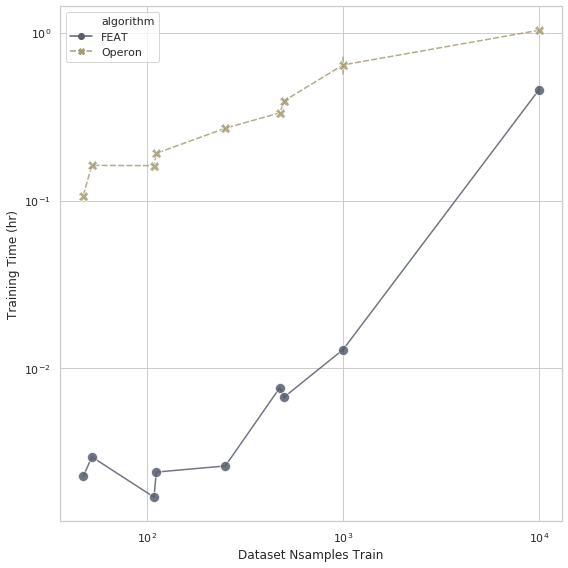

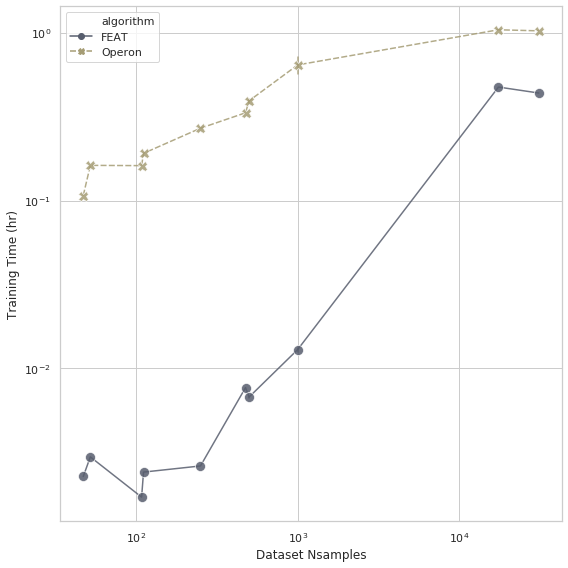

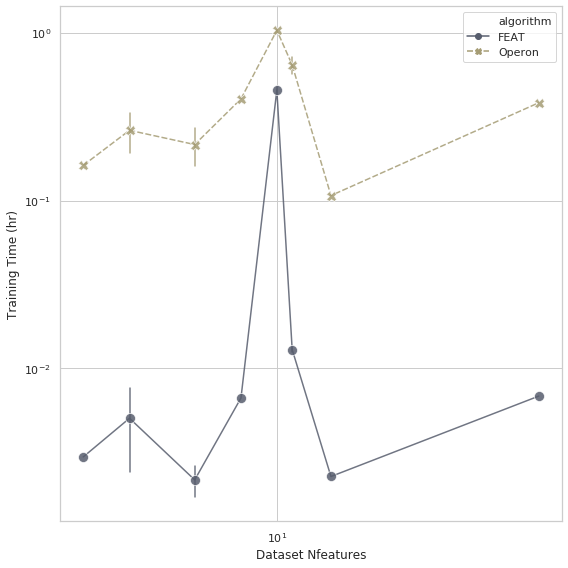

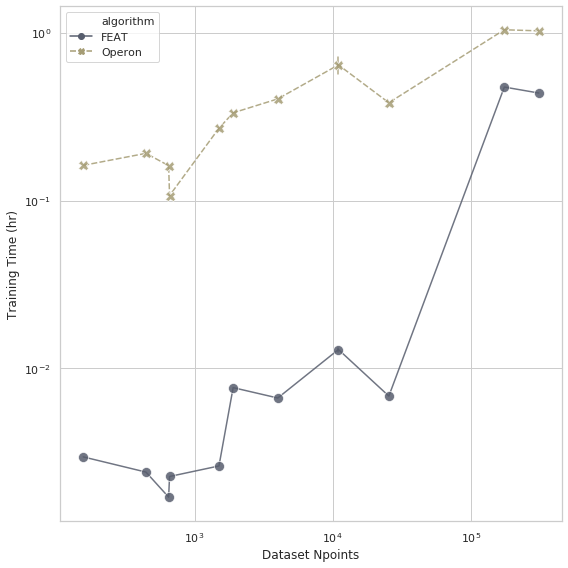

In [7]:
# just some specific algorithms
df_sum_plot = df_sum[df_sum['algorithm'].isin(['FEAT', 'Operon', 'tir'])]

for col in ['dataset_nsamples_train','dataset_nsamples','dataset_nfeatures','dataset_npoints']:
    plt.figure(figsize=(8,8))
    ax = sns.lineplot(
        data=df_sum_plot,
        x = col,
        y = 'training time (hr)',
        hue='algorithm',
        style='algorithm',
        markers=True,
        palette='cividis',
        markersize=10,
        markerfacecolor=None,
        err_style='bars',
        alpha=0.85
    )
    
    ax.set_yscale('log')
    ax.set_xscale('log')
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel('Training Time (hr)')

    save('training_time_'+col)

<!-- # scores on symbolic datasets (prelim) -->

# Pareto plot

Plot the method results as trade-offs between accuracy and simplicity

In [8]:
def bootstrap(val, n = 1000, fn=np.mean):
    val_samples = []
    for i in range(n):
        sample = np.random.randint(0,len(val)-1, size=len(val))
        val_samples.append( fn(val[sample]) )

    m = np.mean(val_samples)
    sd = np.std(val_samples)
    ci_upper  = np.quantile(val_samples,0.95)
    ci_lower  = np.quantile(val_samples,0.05)

    return m, sd, ci_upper,ci_lower

PF: [3, 14, 15, 16, 17, 1, 0, 19]
PF: [13, 26, 21, 7, 22, 5, 12, 20]
PF: [27, 2, 9]
saving ../figs/black-box//pareto_plot_r2_test_rank_model_size_rank.pdf


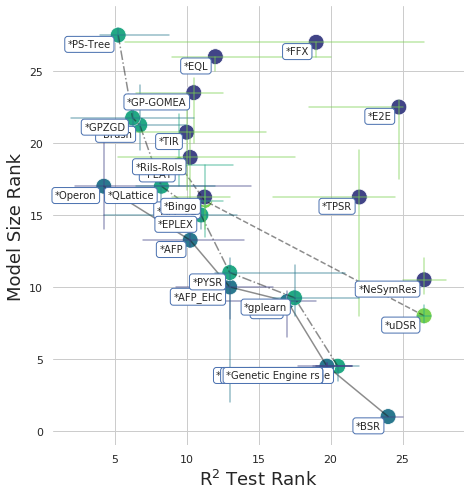

In [9]:
from pareto_utils import front

labelsize=18
ticksize=16
plt.figure(figsize=(7,7))

data = df_sum.copy()

xcol = 'r2_test_rank'
# xcol  = 'r2_test'

ycol = 'model_size_rank'
# ycol = 'model_size'

palette = 'viridis'

# outline pareto front
pareto_data = data.groupby('*algorithm*').median()

objs = pareto_data[[xcol,ycol]].values

# reverse R2 (objs are minimized)
# objs[:,0] = -objs[:,0]

levels = 3 # Change here to include or exclude algorithms
styles=['-','-.','--',':', ':', ':']
PFs = []

pareto_ranks = -np.ones(len(pareto_data))
for el in range(levels):
#     pdb.set_trace()
    PF = front(objs[:,0],objs[:,1])
    if len(PF)>0:
        print('PF:',PF)
        pareto_ranks[PF] = el
    objs[PF,:] = np.inf
    PFs.append(PF)
i = 0
pareto_data.loc[:,'pareto_rank'] = pareto_ranks
for pfset in PFs:
    xset,yset = [],[]

    for pf in pfset:
        xset.append(pareto_data[xcol].values[pf])
        yset.append( pareto_data[ycol].values[pf] )
    plt.plot(xset,yset, styles[i]+'k', alpha=0.5, zorder=1)
#     plt.gca().set_zorder(10)
    i+=1

cmap = sns.color_palette(palette=palette, 
                         n_colors=pareto_data.pareto_rank.nunique(), 
                         desat=None)

ax = sns.scatterplot(
    ax = plt.gca(),
    data = pareto_data,
    x = xcol,
    y = ycol,
    hue = 'pareto_rank',
    s=250,
    legend=False,
    palette=cmap
)

ax.set_zorder(2)
xoff = .5
yoff = 0.3
# xoff, yoff = 0, 0
for idx,row in pareto_data.iterrows(): # Small adjustments to avoid overlap
    x=row[xcol]-xoff
    y=row[ycol]-yoff
    ha='right'
    
    if idx in ['Linear','AFP_FE*','MLP','MRGP*']:
        x=row[xcol]+xoff
        ha='left'
    elif idx == 'Operon*':
        x = row[xcol]+1
        y -= yoff
    elif idx in ['gplearn*','FEAT*']:
#         x -= xoff
#         x=row[xcol]+xoff
        y = row[ycol]+1
#         ha='left'
        
    plt.text(s=idx,
             x = x, 
             y = y,
             ha=ha,
             va='top',
             bbox=dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=1)
            )
    
# confidence intervals
i = 0
for alg, dg in data.groupby('*algorithm*'):
    x = dg[xcol].median() 
    y = dg[ycol].median()
    _, sdx, ciux, cilx = bootstrap(dg[xcol].values, fn=np.median, n=1000)
    _, sdy, ciuy, cily = bootstrap(dg[ycol].values, fn=np.median, n=1000)
    plt.plot(
             [cilx,ciux],
             [y, y],
             alpha=0.5,
             color=cmap[int(pareto_data.loc[alg,'pareto_rank'])]
            )
    plt.plot(
             [x, x],
             [cily,ciuy],
             alpha=0.5,
             color=cmap[int(pareto_data.loc[alg,'pareto_rank'])]
            )
    i += 1

ax.set_aspect(1.0)
# ax.set_xlim(left=0)
# ax.set_ylim(bottom=0)

# plt.xticks([0,5,10,15,20],fontsize=ticksize)
# plt.yticks([0,5,10,15,20],fontsize=ticksize)

plt.xlabel(xcol.replace('_',' ').replace('r2','$R^2$').title(), fontsize=labelsize)
plt.ylabel(ycol.replace('_',' ').title(), fontsize=labelsize)
sns.despine(left=True, bottom=True)

save(name="pareto_plot_"+xcol+'_'+ycol)

In [10]:
objs

array([[  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [11.25, 16.25],
       [  inf,   inf],
       [24.75, 22.5 ],
       [  inf,   inf],
       [12.  , 26.  ],
       [  inf,   inf],
       [19.  , 27.  ],
       [10.5 , 23.5 ],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [26.5 , 10.5 ],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [  inf,   inf],
       [10.25, 19.  ],
       [10.  , 20.75],
       [22.  , 16.25],
       [  inf,   inf],
       [  inf,   inf]])

In [11]:
pareto_data['pareto_rank']

*algorithm*
*AFP                   0.0
*AFP_EHC               0.0
*AFP_FE                2.0
*BSR                   0.0
*Bingo                -1.0
*Brush                 1.0
*E2E                  -1.0
*EPLEX                 1.0
*EQL                  -1.0
*FEAT                  2.0
*FFX                  -1.0
*GP-GOMEA             -1.0
*GPZGD                 1.0
*Genetic Engine        1.0
*Genetic Engine 1p1    0.0
*Genetic Engine hc     0.0
*Genetic Engine rs     0.0
*ITEA                  0.0
*NeSymRes             -1.0
*Operon                0.0
*PS-Tree               1.0
*PYSR                  1.0
*QLattice              1.0
*Rils-Rols            -1.0
*TIR                  -1.0
*TPSR                 -1.0
*gplearn               1.0
*uDSR                  2.0
Name: pareto_rank, dtype: float64

/programs/local/anaconda/2019.10/3/lib/python3.7/site-packages/pandas/core/indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


ValueError: The palette list has the wrong number of colors.

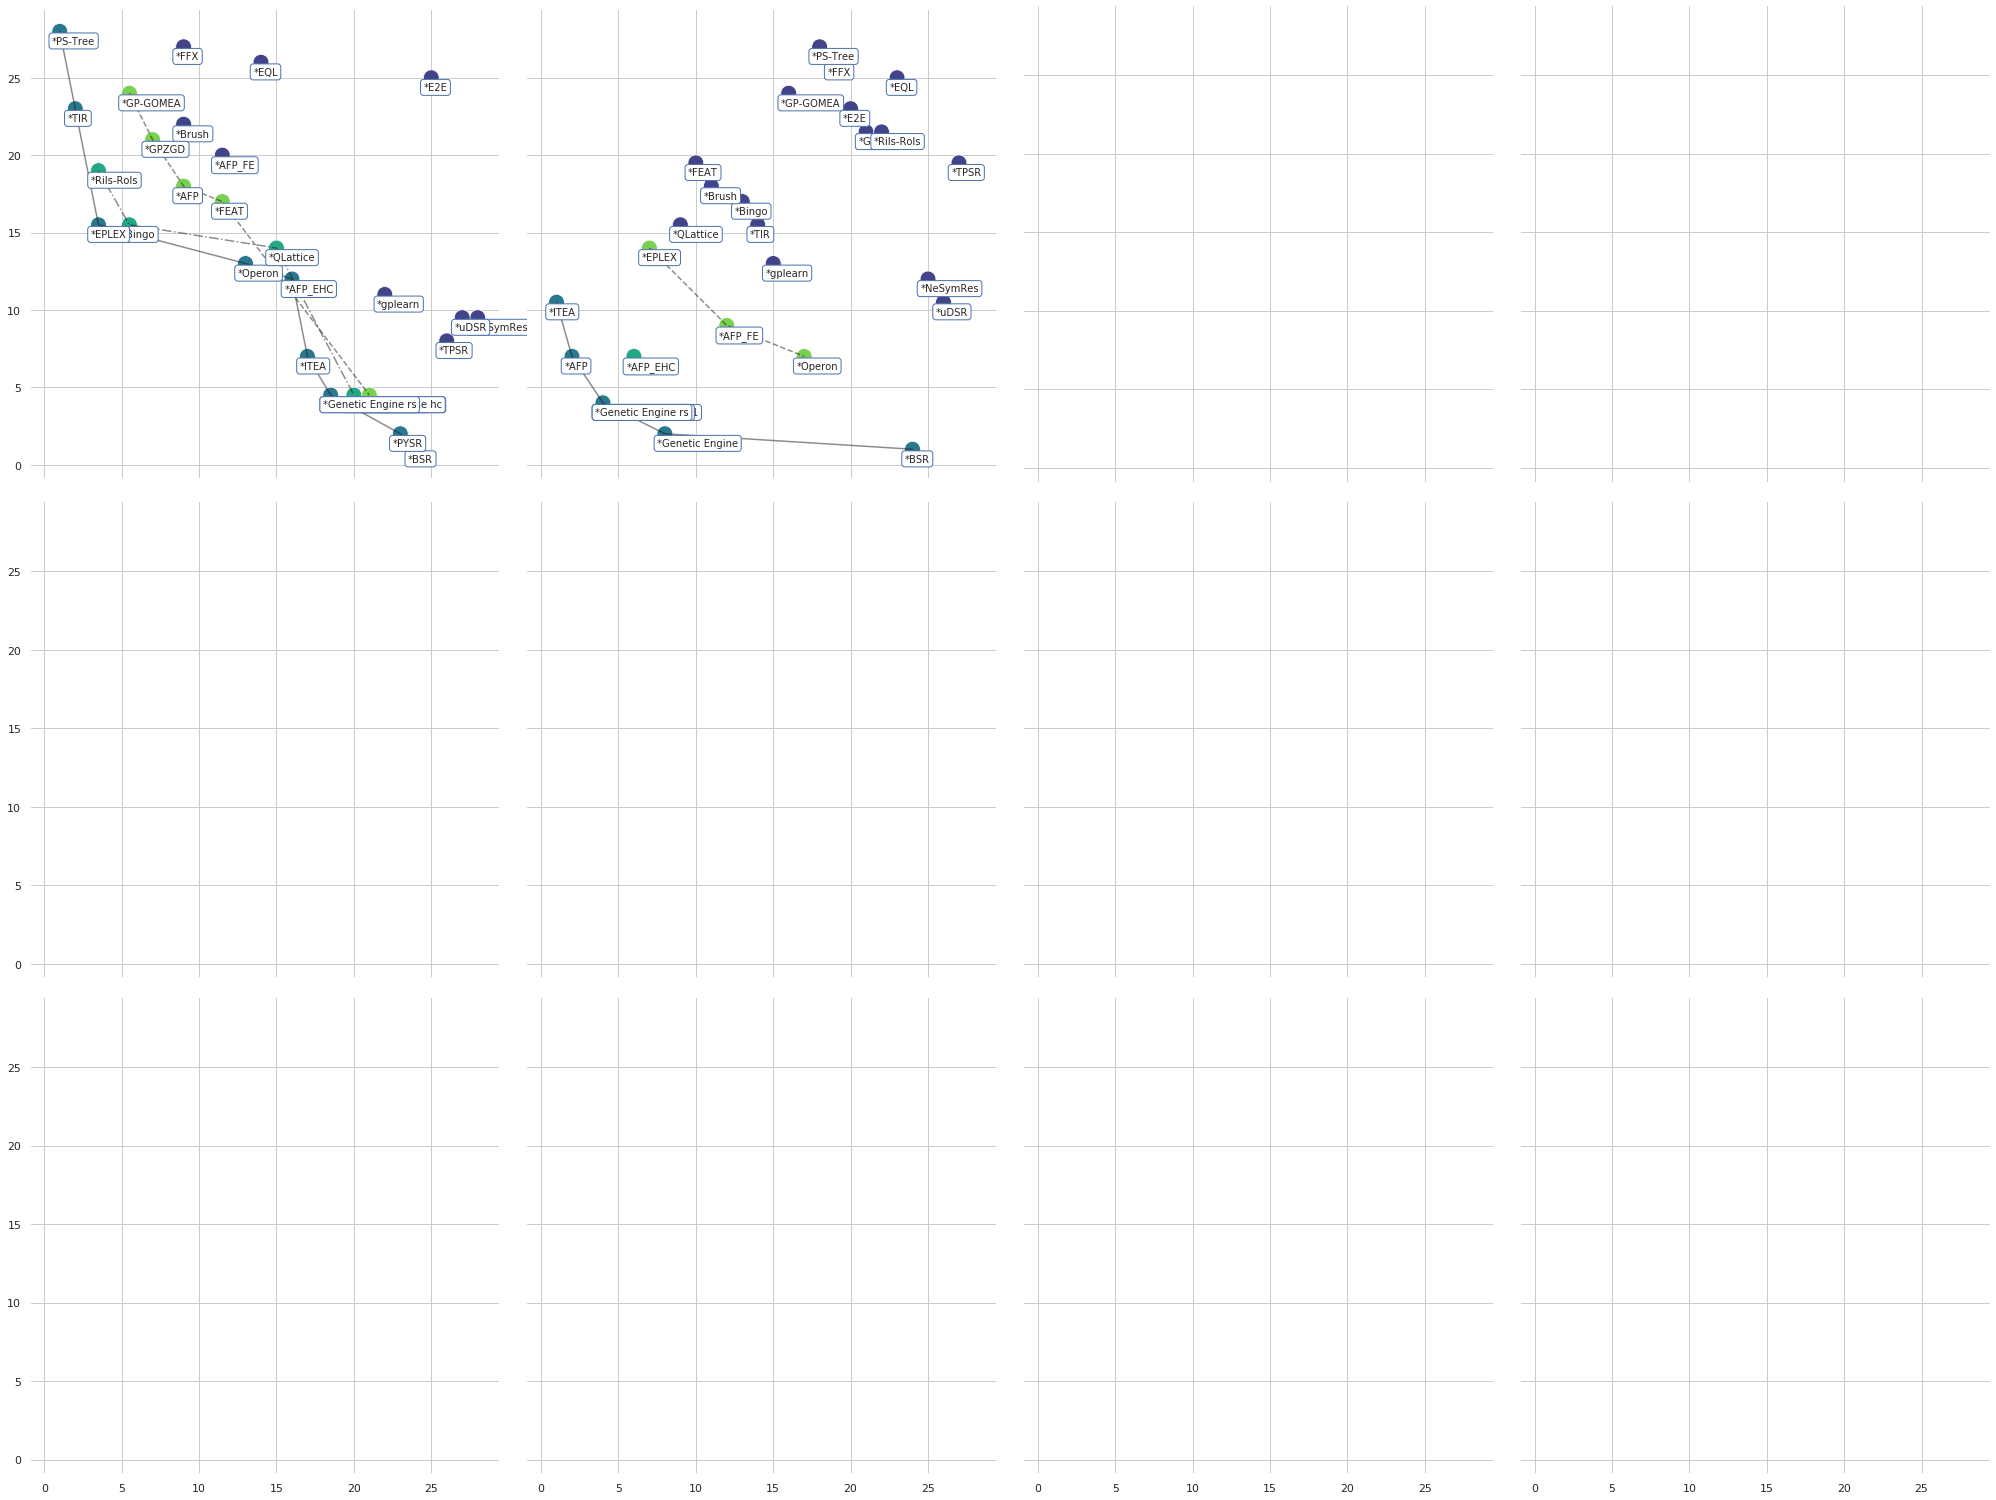

In [12]:
def create_pareto_facets(df_sum,
    facet_column='dataset', xcol = 'r2_test_rank', ycol = 'model_size_rank'):

    pareto_data = df_sum.groupby(['*algorithm*', facet_column]).median()
    data = pareto_data[[xcol,ycol]].reset_index()
    
    levels = 3 # Change here to include or exclude algorithms

    pareto_ranks = -np.ones(len(data))
    for val in data[facet_column].unique():
        objs = data[data[facet_column]==val]
        for el in range(levels):
            PF = front(objs.loc[:,xcol].values, objs.loc[:,ycol].values)
            if len(PF)>0:
                pareto_ranks[objs.iloc[PF].index] = el
            objs.iloc[PF,:] = np.inf

    data.loc[:,'pareto_rank'] = pareto_ranks

    # Initialize FacetGrid
    g = sns.FacetGrid(
        data,
        col=facet_column,
        height=7,
        aspect=1,
        col_wrap=4,
        margin_titles=True,
    )
    
    def custom_plot(data, **kwargs):
        cmap = sns.color_palette("viridis", n_colors=levels+1)

        # Create scatter plot
        ax = sns.scatterplot(
            data=data,
            x=xcol,
            y=ycol,
            hue='pareto_rank',
            s=250,
            palette=cmap,
            legend=False
        )
        
        styles=['-','-.','--',':', ':', ':']
        for el in range(levels):
            pfset = data[data['pareto_rank']==el].sort_values(by=[xcol, ycol])
            ax.plot(pfset[xcol], pfset[ycol], styles[el]+'k', alpha=0.5, zorder=1)
            
        # # Add confidence intervals
        # for alg, dg in data.groupby('*algorithm*'):
        #     x = dg[xcol].median() 
        #     y = dg[ycol].median()
        #     if len(dg)<=1: continue
        #     _, sdx, ciux, cilx = bootstrap(dg[xcol].values, fn=np.median, n=1000)
        #     _, sdy, ciuy, cily = bootstrap(dg[ycol].values, fn=np.median, n=1000)
        #     plt.plot(
        #             [cilx,ciux],
        #             [y, y],
        #             alpha=0.5,
        #             color=cmap[int(data.loc[alg,'pareto_rank'])]
        #             )
        #     plt.plot(
        #             [x, x],
        #             [cily,ciuy],
        #             alpha=0.5,
        #             color=cmap[int(data.loc[alg,'pareto_rank'])]
        #             )
            
        # # Add labels
        xoff, yoff = .5, 0.3
        for idx, row in data.iterrows():
            ax.text(s=row['*algorithm*'], x=row[xcol]-xoff, y=row[ycol]-yoff, ha='left', va='top',
                   bbox=dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=1))
        
        ax.set_aspect(1.0)
        sns.despine(left=True, bottom=True)
        return ax
    
    g.map_dataframe(custom_plot, col=facet_column)
    return g

create_pareto_facets(df_sum)

## Clustermaps

In [ ]:
data = df_sum.copy()

df_clustermap = data[["dataset", "algorithm", "r2_test_rank"]]\
        .groupby(["dataset", "algorithm"]).mean().reset_index().pivot(
            "dataset", columns="algorithm").fillna(data["algorithm"].nunique())

df_clustermap.columns = df_clustermap.columns.droplevel()

g = sns.clustermap(
    df_clustermap.T,
    figsize=(10, 14)
)

for ticklbl in g.ax_heatmap.xaxis.get_ticklabels():
    if "Brush" in ticklbl.get_text():
        ticklbl.set_bbox(dict(facecolor='lightblue', edgecolor='w', alpha=1, pad=0)) # boxstyle='round',
        # ticklbl.set_c('blue')

g.ax_heatmap.set_xlabel("Algorithm")
g.ax_heatmap.set_ylabel("Dataset")

plt.tight_layout()
save(name="clustermap")